# 3 Data processing

This section prepares raw tracking data from all experiments for downstream analysis.

Time-lapse image sequences of different strains and experiments were analyzed using **TrackMate v7.12** in **FIJI**. Tracking was performed in batch mode using the **TrackMate batch processor** with a consistent parameter file located at:

`/02_data/trackmate_settings.xml`

From each time series, the resulting CSV exports (`spots`, `edges`, `tracks`) were collected and parsed. The data were then cleaned, standardized, and stored in a uniform structure. This workflow ensures full reproducibility across experiments and consistent input for trajectory analysis.

## 1 Setup

### Load libraries

In [1]:
library(tidyverse)
library(RColorBrewer)
library(patchwork)
library(circular)
library(zoo)
library(svglite)
library(ggforce)
library(IRdisplay)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘circular’


The following objects are masked from ‘package:stats’:

    sd, var



Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




### Set working directory

In [ ]:
wd <- "/path/to//03_image_analysis/02_chemotaxis_towards_cAMP"
setwd(wd)


### Define colors

In [3]:
# Define base colors for each strain using ColorBrewer palettes
wt_colors     <- brewer.pal(n = 9, name = "Greens")
disfp_colors  <- brewer.pal(n = 9, name = "Purples")
rescue_colors <- brewer.pal(n = 9, name = "Blues")

# Pick midtones for standard fill color
color_nr <- 6
strain_colors <- c(
  "wt" = wt_colors[color_nr],
  "ko" = disfp_colors[color_nr],
  "re" = rescue_colors[color_nr]
)

# Pick dark tones for outlines or emphasis
color_nr_dark <- 9
strain_colors_dark <- c(
  "wt" = wt_colors[color_nr_dark],
  "ko" = disfp_colors[color_nr_dark],
  "re" = rescue_colors[color_nr_dark]
)

# Define strain label expressions for parsed plot labels
strain_rename <- c(
  "ko" = expression(atop(italic(disfp)^"–", " mutant")),
  "re" = expression(atop(italic(disfp)^"–", " rescue")), 
  "wt" = expression(atop("Ax2", "wildtype"))
)

### Define parameters

In [4]:
# Time resolution of the imaging system
time_between_frames <- 0.5  # seconds

# Spatial calibration (pixel to micron conversion)
pixels_x <- 2049
pixels_y <- 3877

physical_length_in_uM_x <- 1339.23
physical_length_in_uM_y <- 2534.59

scale_factor_x <- physical_length_in_uM_x / pixels_x
scale_factor_y <- physical_length_in_uM_y / pixels_y

# Final isotropic scaling factor (manually enforced)
scale_factor <- (scale_factor_x + scale_factor_y) / 2
scale_factor <- 0.654  # Override with final rounded value used throughout

# Define consistent strain order
strain_levels <- c("wt", "ko", "re")

# For reproducibility in sampling
set.seed(123)


### Load data

In [5]:
# Define input folder
csv_folder_path <- paste0(wd, "/data/trackmate/csv_combined/")

# Get list of all CSVs in the folder
csv_paths <- list.files(csv_folder_path, pattern = "\\.csv$", full.names = TRUE)

# Load all CSVs into a named list of dataframes
dataframes_list <- list()
for (path in csv_paths) {
  base_name <- tools::file_path_sans_ext(basename(path))
  df <- read.csv(path, header = TRUE, check.names = TRUE, sep = ",")
  dataframes_list[[base_name]] <- df
}


Extract spot, edge, and track tables from imported list

In [6]:
spots_df <- dataframes_list[["spots"]]
edges_df <- dataframes_list[["edges"]]
tracks_df <- dataframes_list[["tracks"]]

## Analysis and Visualization

### Prepare the data

 Generate unique ID and flip, remap coordinates

In [7]:
# Combine experiment, strain, and track ID into a unique identifier
spots_df$full_track_id <- paste(spots_df$exp, spots_df$strain, spots_df$track_id, sep = "_")

# Copy original dataframe for manipulation
tracking_data <- spots_df

# Flip X-axis and swap axis convention
# → This assumes position_x is left-to-right (to be mirrored), and you want y := flipped-x, x := original-y
tracking_data <- tracking_data %>%
  mutate(
    position_x = max(position_x) - position_x,  # Flip horizontally
    y = position_x,
    x = position_y,
    position_x = x,
    position_y = y
  )


 Align all tracks to a common origin (0,0)

In [8]:
# Extract the initial (x, y) coordinates per track (based on the first frame)
initial_coordinates <- tracking_data %>%
  group_by(full_track_id) %>%
  filter(frame == min(frame)) %>%
  select(full_track_id, initial_x = x, initial_y = y)

# Subtract initial coordinates → normalize all tracks to (0,0)
tracking_data <- tracking_data %>%
  left_join(initial_coordinates, by = "full_track_id") %>%
  mutate(
    x_origin = ifelse(is.na(initial_x), 0, x - initial_x),
    y_origin = ifelse(is.na(initial_y), 0, y - initial_y)
  ) %>%
  mutate(strain = factor(strain, levels = strain_levels)) %>%
  arrange(exp, strain, track_id, frame)

 Compute full metrics before filtering

In [9]:
# Compute distance, net displacement, FMI, speed, and direction per track across all frames
tracking_data <- tracking_data %>%
  group_by(exp, strain, track_id) %>%
  mutate(
    # Frame-to-frame deltas
    delta_x = x_origin - lag(x_origin, default = first(x_origin)),
    delta_y = y_origin - lag(y_origin, default = first(y_origin)),
    distance = sqrt(delta_x^2 + delta_y^2),
    
    # Cumulative distance along the path
    accum_distance = cumsum(distance),
    
    # Net displacement (current point vs. start)
    net_x = x_origin - first(x_origin),
    net_y = y_origin - first(y_origin),
    
    # Euclidean distance from start (direct distance)
    euclid_distance = sqrt(net_x^2 + net_y^2),
    
    # FMI: how straight the movement is in each direction
    FMI_x = net_x / accum_distance,
    FMI_y = net_y / accum_distance,
    
    # Directness: ratio of straight-line vs. actual path length
    Directness = euclid_distance / accum_distance,
    
    # Original image coordinates (optional for reference)
    raw_start_x = first(position_x),
    raw_start_y = first(position_y),
    raw_end_x = last(position_x),
    raw_end_y = last(position_y),
    
    # Frame and timing metrics
    track_start_frame = first(frame),
    track_end_frame = last(frame),
    track_duration = track_end_frame - track_start_frame + 1,
    
    # Speed
    speed_pixels_per_sec = distance / time_between_frames,
    speed_um_per_sec = speed_pixels_per_sec * scale_factor,
    
    # Replicate summary values across the track
    total_distance = last(accum_distance),
    total_FMI_x = last(FMI_x),
    total_FMI_y = last(FMI_y),
    total_euclid_distance = last(euclid_distance),
    total_Directness = last(Directness),
    x_end = last(x_origin),
    y_end = last(y_origin)
  ) %>%
  ungroup()


Filter for the targeted time interval and recalculate the full metrics

In [10]:
# Cut to frame 0–400 and recalculate core metrics
tracking_data_400 <- tracking_data %>%
  filter(between(frame, 0, 400)) %>%
  arrange(exp, strain, track_id, frame) %>%
  group_by(exp, strain, track_id) %>%
  mutate(
    delta_x = x_origin - lag(x_origin, default = first(x_origin)),
    delta_y = y_origin - lag(y_origin, default = first(y_origin)),
    distance = sqrt(delta_x^2 + delta_y^2),
    accum_distance = cumsum(distance),
    net_x = x_origin - first(x_origin),
    net_y = y_origin - first(y_origin),
    euclid_distance = sqrt(net_x^2 + net_y^2),
    FMI_x = net_x / accum_distance,
    FMI_y = net_y / accum_distance,
    Directness = euclid_distance / accum_distance,
    track_start_frame = first(frame),
    track_end_frame = last(frame),
    track_duration = track_end_frame - track_start_frame + 1,
    speed_pixels_per_sec = distance / time_between_frames,
    speed_um_per_sec = speed_pixels_per_sec * scale_factor,
    total_distance = last(accum_distance),
    total_FMI_x = last(FMI_x),
    total_FMI_y = last(FMI_y),
    total_euclid_distance = last(euclid_distance),
    total_Directness = last(Directness),
    x_end = last(x_origin),
    y_end = last(y_origin)
  ) %>%
  ungroup()


Now apply filters to the data within the selected time intervall

In [11]:
# Filter only after recalculating on sliced data
filtered_tracking_data <- tracking_data_400 %>%
  mutate(strain = factor(strain, levels = c("wt", "ko", "re"))) %>%
  filter(
    track_start_frame == 0,
    track_duration >= 20,
    total_euclid_distance >= 400
  ) %>%
  mutate(
    final_angle_rad = atan2(y_end, x_end),
    unit_circle_x = cos(final_angle_rad),
    unit_circle_y = sin(final_angle_rad)
  ) %>%
  arrange(exp, strain, track_id, frame)

filtered_tracking_data$full_track_id <- paste(
  filtered_tracking_data$exp,
  filtered_tracking_data$strain,
  filtered_tracking_data$track_id,
  sep = "_"
)

Calculate frame-wise speed summary

In [12]:
tracking_data_speed_sum <- tracking_data %>%
  group_by(exp, strain, frame) %>%
  summarise(mean_speed_um_per_sec = mean(speed_um_per_sec), .groups = "drop")

Downsample for visualization

In [13]:
# Identify unique tracks for sampling
sampled_tracks <- filtered_tracking_data %>%
  distinct(exp, strain, track_id) %>%
  group_by(exp, strain) %>%
  sample_n(size = min(n(), 60)) %>%
  ungroup()

# Keep only those sampled tracks in the filtered dataset
filtered_tracking_data <- filtered_tracking_data %>%
  semi_join(sampled_tracks, by = c("exp", "strain", "track_id"))


 Summarize filtered tracks (per cell)

In [14]:
# Summarize each track into one row with final values
filtered_track_summary <- filtered_tracking_data %>%
  group_by(full_track_id) %>%
  arrange(exp, strain, track_id, frame) %>%
  summarise(
    exp = first(exp),
    strain = first(strain),
    track_id = first(track_id),
    track_start_frame = first(track_start_frame),
    track_end_frame = last(track_end_frame),
    track_duration = first(track_duration),
    total_distance = last(accum_distance),
    total_euclid_distance = last(euclid_distance),
    total_Directness = last(Directness),
    total_FMI_x = last(FMI_x),
    total_FMI_y = last(FMI_y),
    final_angle_rad = last(final_angle_rad),
    unit_circle_x = last(unit_circle_x),
    unit_circle_y = last(unit_circle_y),
    .groups = "drop"
  ) %>%
  arrange(exp, strain, track_id)


Calculate per-group means

In [15]:
# Calculate group-level means (per strain and experiment)
means_by_strain_exp <- filtered_track_summary %>%
  group_by(exp, strain) %>%
  summarise(
    mean_Directness = mean(total_Directness, na.rm = TRUE),
    mean_FMI_y = mean(total_FMI_y, na.rm = TRUE),
    mean_FMI_x = mean(total_FMI_x, na.rm = TRUE),
    .groups = "drop"
  )


add addition columns for annotation of plots

In [16]:
# Facet label expressions (parsed later)
strain_rename_facet <- c(
  "wt" = "atop('Ax2', 'wild-type')",
  "ko" = "atop(italic(disfp)^'–', ' mutant')",
  "re" = "atop(italic(disfp)^'–', ' rescue')"
)

# Compute symmetric axis limits for plotting
max_abs_value <- max(abs(range(
  filtered_tracking_data$x_end,
  filtered_tracking_data$y_end
)))

common_limits <- c(-max_abs_value, max_abs_value)

# Apply final labeling
filtered_tracking_data$strain_full <- factor(
  filtered_tracking_data$strain,
  levels = names(strain_rename_facet),
  labels = strain_rename_facet
)

### Plot migration paths
in raw coordinates

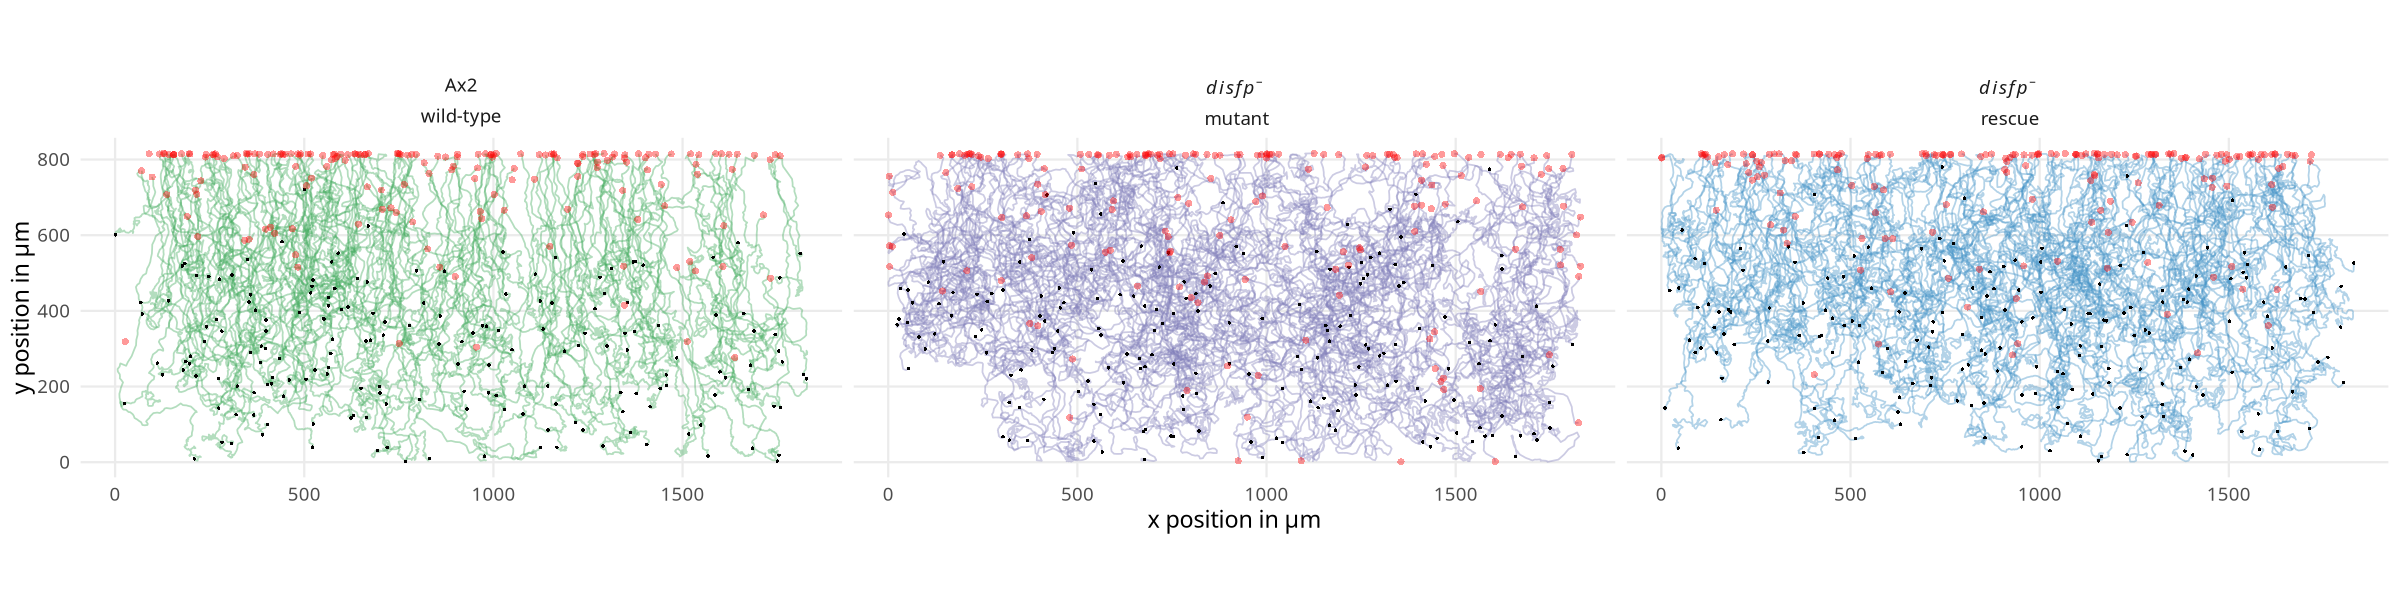

In [17]:
p_raw_tracks <- filtered_tracking_data %>%
  ggplot(aes(x = position_x * scale_factor, y = position_y * scale_factor, group = full_track_id)) + 
  geom_path(aes(color = strain), alpha = 0.4) +
  geom_point(data = . %>% distinct(full_track_id, .keep_all = TRUE),
             aes(x = raw_start_x * scale_factor, y = raw_start_y * scale_factor),
             fill = "black", color = "black", size = 1, shape = 21, stroke = NA) +
  geom_point(data = . %>% distinct(full_track_id, .keep_all = TRUE),
             aes(x = raw_end_x * scale_factor, y = raw_end_y * scale_factor),
             fill = "red", color = "red", size = 2, shape = 21, stroke = NA, alpha = 0.4) +
  scale_color_manual(values = strain_colors) +
  theme_minimal(base_size = 14) +
  facet_wrap(~ strain_full, labeller = label_parsed) +
  coord_fixed(ratio = 1) +  # preserve aspect ratio
  labs(x = "x position in µm", y = "y position in µm") +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank()
  )

options(repr.plot.width = 20, repr.plot.height = 5)
p_raw_tracks


relative to origin (0,0)

In [18]:
p_origin_tracks <- filtered_tracking_data %>%
  ggplot(aes(x = x_origin * scale_factor, y = y_origin * scale_factor, group = full_track_id)) + 
  geom_path(aes(color = strain), alpha = 0.2, linewidth = 0.25) +
  geom_point(data = . %>% distinct(full_track_id, .keep_all = TRUE),
             aes(x = x_end * scale_factor, y = y_end * scale_factor),
             fill = "red", color = "red", size = 0.5, shape = 21, stroke = NA, alpha = 0.4) +
  scale_color_manual(values = strain_colors) +
  theme_minimal(base_size = 8) +
  facet_wrap(~ strain_full, labeller = label_parsed) +
  coord_fixed(ratio = 1) +
  labs(x = "Δx in µm", y = "Δy in µm") +
  xlim(-450, 450) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold", size = 8),
    axis.text = element_text(size = 8, color = "black"),
    strip.text = element_blank()
  )

# Save as transparent SVG
save_path <- file.path(wd, "05_results", "img", "chemotaxis_paths.svg")
ggsave(save_path, plot = p_origin_tracks, width = 87 / 25.4, height = 40.5 / 25.4,
       units = "in", bg = "transparent", device = svglite, create.dir = TRUE)

# Display preview (Jupyter only)
display_html(sprintf('<img src="%s" style="height:1.5vh; width:auto; background-color:white;">', save_path))


Warning message:
“Removed 85 rows containing missing values or values outside the scale range
(`geom_path()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


### Plot circular distribution

#### Circular statistics

In [19]:
# Convert angles to circular objects
wt_angle <- circular(
  filtered_track_summary %>% filter(strain == "wt") %>% pull(final_angle_rad),
  units = "radians"
)
ko_angle <- circular(
  filtered_track_summary %>% filter(strain == "ko") %>% pull(final_angle_rad),
  units = "radians"
)
re_angle <- circular(
  filtered_track_summary %>% filter(strain == "re") %>% pull(final_angle_rad),
  units = "radians"
)

# Watson-Wheeler pairwise comparisons
test_results <- list(
  "WT vs KO" = watson.wheeler.test(list(wt_angle, ko_angle)),
  "WT vs RE" = watson.wheeler.test(list(wt_angle, re_angle)),
  "RE vs KO" = watson.wheeler.test(list(re_angle, ko_angle))
)

# Tidy results
results_df <- tibble(
  pair = names(test_results),
  p_value = map_dbl(test_results, ~ .x$p.value)
) %>%
  mutate(
    p_adj = p.adjust(p_value, method = "bonferroni"),
    significance = case_when(
      p_adj < 0.001 ~ "***",
      p_adj < 0.01  ~ "**",
      p_adj < 0.05  ~ "*",
      TRUE          ~ ""
    )
  )

#### Plotting circular endpoint distributions

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”


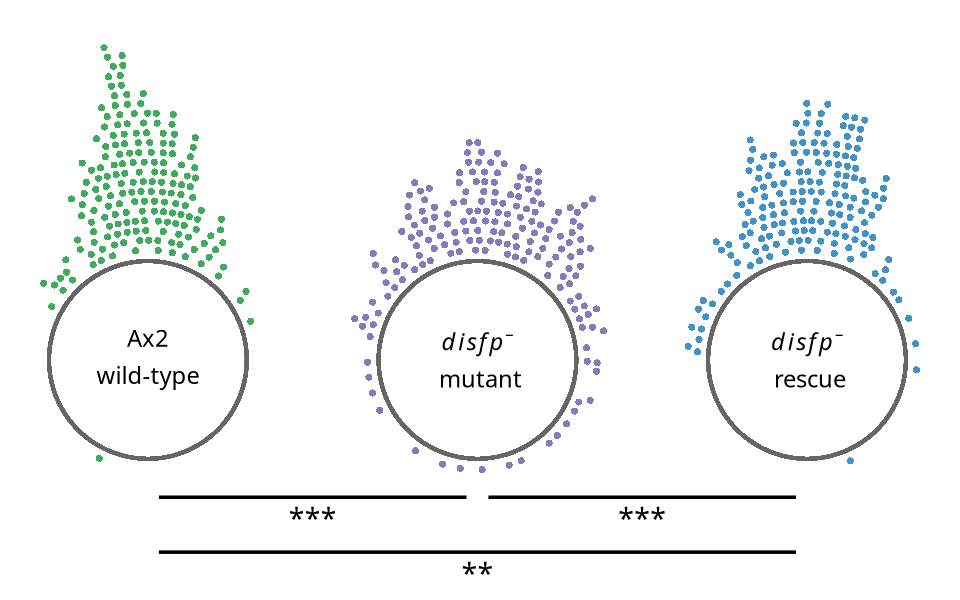

In [20]:
# Parameters for overlap avoidance
high_density_threshold <- 40
closeness_threshold <- 0.01
radius_decrement <- 0.089
initial_high_density_radius <- 1 - radius_decrement
minimum_distance_for_overlap <- 0.075

# Prepare Cartesian coordinates and density estimates
adjusted_track_summary <- filtered_track_summary %>%
  mutate(
    x = cos(final_angle_rad),
    y = sin(final_angle_rad)
  ) %>%
  group_by(strain) %>%
  mutate(
    density = map_dbl(seq_along(x), ~sum(sqrt((x - x[.x])^2 + (y - y[.x])^2) < closeness_threshold)),
    radius_adjusted = if_else(density > high_density_threshold, initial_high_density_radius, 1)
  ) %>%
  ungroup()

# Function to adjust radius iteratively to reduce overlap
adjust_radius <- function(df) {
  for (i in 1:nrow(df)) {
    distances <- sqrt((df$x - df$x[i])^2 + (df$y - df$y[i])^2)
    while (any(distances < minimum_distance_for_overlap & distances > 0, na.rm = TRUE)) {
      df$radius_adjusted[i] <- df$radius_adjusted[i] + radius_decrement
      df$x[i] <- df$radius_adjusted[i] * cos(df$final_angle_rad[i])
      df$y[i] <- df$radius_adjusted[i] * sin(df$final_angle_rad[i])
      distances <- sqrt((df$x - df$x[i])^2 + (df$y - df$y[i])^2)
    }
  }
  df
}

# Apply radius adjustment per strain group
adjusted_track_summary <- adjusted_track_summary %>%
  group_by(strain) %>%
  nest() %>%
  mutate(data = map(data, adjust_radius)) %>%
  unnest(data) %>%
  ungroup()

# Shift groups to show all in one plot
adjusted_track_summary <- adjusted_track_summary %>%
  mutate(
    x_shifted = case_when(
      strain == "ko" ~ x + 3,
      strain == "re" ~ x + 6,
      TRUE ~ x
    )
  )

# Annotation data
annotations_label <- data.frame(
  strain = factor(c("ko", "re", "wt"), levels = strain_levels),
  x = c(3, 6, 0),
  y = c(0, 0, 0),
  label = c(
    "atop(italic(disfp)^'–', ' mutant')",
    "atop(italic(disfp)^'–', ' rescue')",
    "atop('Ax2', 'wild-type')"
  )
)

annotations_watson <- data.frame(
  x_min = c(0.1, 0.1, 3.1),
  x_max = c(2.9, 5.9, 5.9),
  y = c(-1.25, -1.75, -1.25),
  label = results_df$significance
)

# Final plot
p_circle <- adjusted_track_summary %>%
  ggplot(aes(x = x_shifted, y = y, fill = strain, color = strain)) +
  geom_circle(aes(x0 = 0, y0 = 0, r = .9), color = "grey40", fill = NA, linewidth = 1) +
  geom_circle(aes(x0 = 3, y0 = 0, r = .9), color = "grey40", fill = NA, linewidth = 1) +
  geom_circle(aes(x0 = 6, y0 = 0, r = .9), color = "grey40", fill = NA, linewidth = 1) +
  geom_point(shape = 21, size = 2, stroke = NA, alpha = 1) +
  geom_segment(data = annotations_watson, aes(x = x_min, xend = x_max, y = y, yend = y),
               inherit.aes = FALSE, color = "black", size = 1) +
  geom_text(data = annotations_watson, aes(x = (x_min + x_max) / 2, y = y, label = label),
            inherit.aes = FALSE, vjust = 1.5, size = 6) +
  geom_label(data = annotations_label, aes(x = x, y = y, label = label),
             parse = TRUE, inherit.aes = FALSE, fill = NA, label.size = NA, size = 5) +
  scale_fill_manual(values = strain_colors) +
  scale_color_manual(values = strain_colors_dark) +
  coord_fixed() +
  theme_void(base_size = 14) +
  guides(fill = FALSE, color = FALSE)

options(repr.plot.width = 8, repr.plot.height = 5)
p_circle


### Forward migration index

#### Perform ANOVA

In [21]:
# ANOVA for total_FMI_x
anova_fmi_x <- aov(mean_FMI_x ~ strain, data = means_by_strain_exp)
tukey_test_fmi_x <- TukeyHSD(anova_fmi_x)
tukey_results_fmi_x <- tukey_test_fmi_x$strain
tukey_results_fmi_x <- data.frame(Comparison = rownames(tukey_results_fmi_x), tukey_results_fmi_x) %>%
  mutate(significance = case_when(
    p.adj < 0.001 ~ "***",
    p.adj < 0.01  ~ "**",
    p.adj < 0.05  ~ "*",
    TRUE          ~ ""
  ))

# ANOVA for total_FMI_y
anova_fmi_y <- aov(mean_FMI_y ~ strain, data = means_by_strain_exp)
tukey_test_fmi_y <- TukeyHSD(anova_fmi_y)
tukey_results_fmi_y <- tukey_test_fmi_y$strain
tukey_results_fmi_y <- data.frame(Comparison = rownames(tukey_results_fmi_y), tukey_results_fmi_y) %>%
  mutate(significance = case_when(
    p.adj < 0.001 ~ "***",
    p.adj < 0.01  ~ "**",
    p.adj < 0.05  ~ "*",
    TRUE          ~ ""
  ))


#### Plot the results
FMI(x) - perpendicular to the cAMP gradient

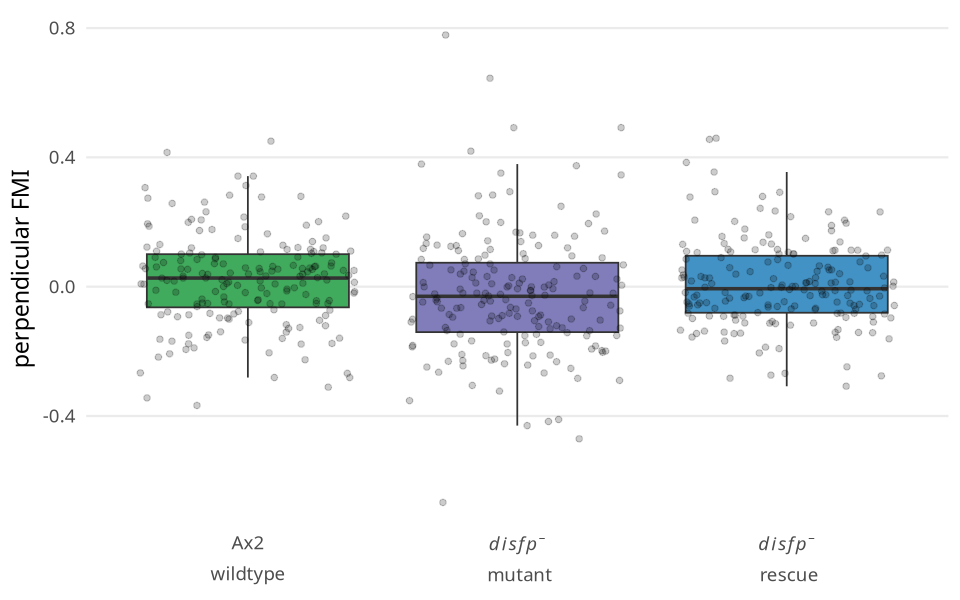

In [22]:
# Setup for significance annotation line
y_sigline_fmi_x <- 0.8

annotations_fmi_x <- data.frame(
  x_min = c(1.1, 1.1, 2.1),
  x_max = c(1.9, 2.9, 2.9),
  y = c(y_sigline_fmi_x - 0.1, y_sigline_fmi_x - 0.2, y_sigline_fmi_x - 0.3),
  label = tukey_results_fmi_x$significance,
  pvalue = tukey_results_fmi_x$p.adj
) %>% filter(pvalue <= 0.05)

# Boxplot of FMI(x) with jitter and annotations
p_FMI_x <- filtered_track_summary %>% 
  ggplot(aes(x = strain, y = -total_FMI_x, fill = strain)) +
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(alpha = 0.2) +
    scale_fill_manual(values = strain_colors) +
    scale_x_discrete(labels = strain_rename) +
    labs(x = NULL, y = "perpendicular FMI") +
    theme_minimal(base_size = 14) +
    guides(fill = FALSE, color = FALSE) +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank()
    )

options(repr.plot.width = 8, repr.plot.height = 5)
p_FMI_x


FMI(y) - parallel to the cAMP gradient

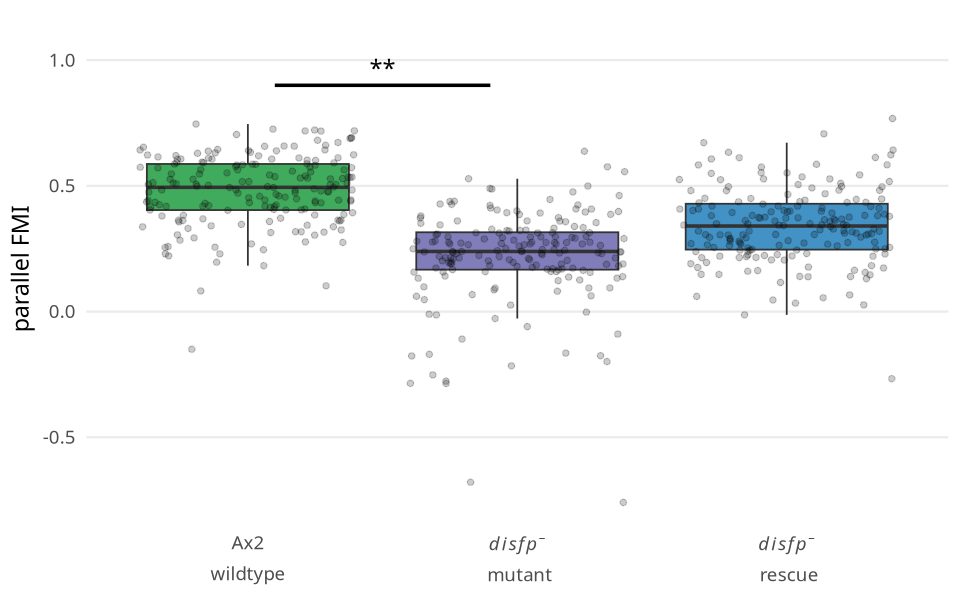

In [23]:
# Setup for significance annotation line
y_sigline_fmi_y <- 1.0

annotations_fmi_y <- data.frame(
  x_min = c(1.1, 1.1, 2.1),
  x_max = c(1.9, 2.9, 2.9),
  y = c(y_sigline_fmi_y - 0.1, y_sigline_fmi_y - 0.2, y_sigline_fmi_y - 0.3),
  label = tukey_results_fmi_y$significance,
  pvalue = tukey_results_fmi_y$p.adj
) %>% filter(pvalue <= 0.05)

# Boxplot of FMI(y) with jitter and significance annotations
p_FMI_y <- filtered_track_summary %>% 
  ggplot(aes(x = strain, y = total_FMI_y, fill = strain)) + 
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(alpha = 0.2) +
    geom_segment(data = annotations_fmi_y,
                 aes(x = x_min, xend = x_max, y = y, yend = y),
                 inherit.aes = FALSE, color = "black", size = 1) +
    geom_text(data = annotations_fmi_y,
              aes(x = (x_min + x_max) / 2, y = y, label = label),
              inherit.aes = FALSE, vjust = -0.5, size = 5) +
    scale_fill_manual(values = strain_colors) +
    scale_x_discrete(labels = strain_rename) +
    labs(x = NULL, y = "parallel FMI") +
    ylim(c(NA, 1.1)) +
    theme_minimal(base_size = 14) +
    guides(fill = FALSE, color = FALSE) +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank()
    )

options(repr.plot.width = 8, repr.plot.height = 5)
p_FMI_y


### Directness

#### Anova

In [24]:
# ANOVA on mean directness values per strain
anova_directness <- aov(mean_Directness ~ strain, data = means_by_strain_exp)

# Tukey's post-hoc test
tukey_test_directness <- TukeyHSD(anova_directness)
tukey_results_directness <- tukey_test_directness$strain

# Format Tukey results with significance symbols
tukey_results_directness <- data.frame(Comparison = rownames(tukey_results_directness), tukey_results_directness) %>%
  mutate(significance = case_when(
    p.adj < 0.001 ~ "***",
    p.adj < 0.01  ~ "**",
    p.adj < 0.05  ~ "*",
    TRUE          ~ ""
  ))


#### Plot the results

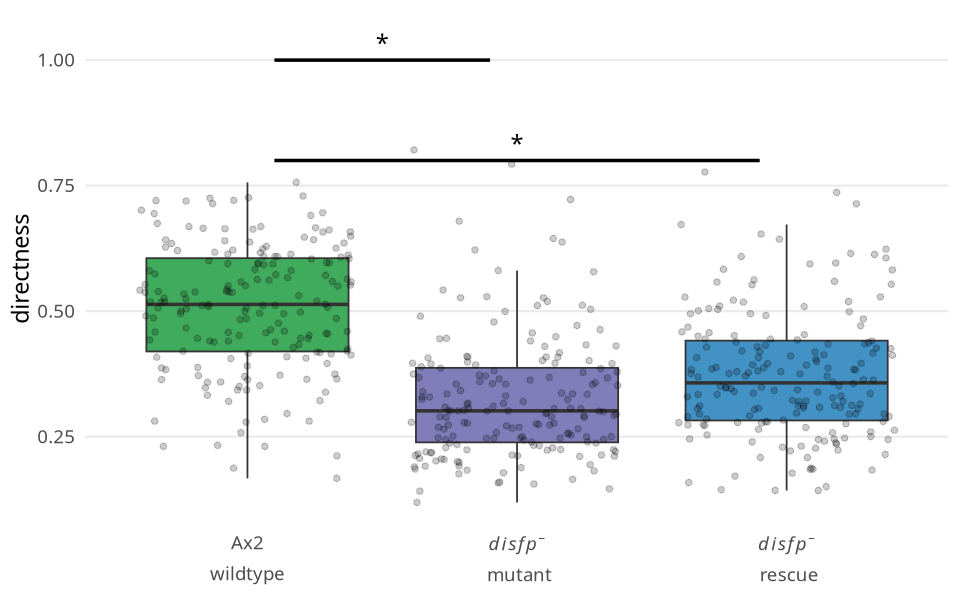

In [25]:
# Position for significance lines
y_sigline_directness <- 1.05

# Build annotation segments and labels
annotations_directness <- data.frame(
  x_min = c(1.1, 1.1, 2.1),
  x_max = c(1.9, 2.9, 2.9),
  y = c(y_sigline_directness - 0.05, y_sigline_directness - 0.25, y_sigline_directness - 0.45),
  label = tukey_results_directness$significance,
  pvalue = tukey_results_directness$p.adj
) %>% filter(pvalue <= 0.05)

# Plot Directness per strain with significance annotation
p_directness <- filtered_track_summary %>% 
  ggplot(aes(x = strain, y = total_Directness, fill = strain)) + 
    geom_boxplot(outlier.shape = NA) +
    geom_jitter(alpha = 0.2) +
    geom_segment(data = annotations_directness,
                 aes(x = x_min, xend = x_max, y = y, yend = y),
                 inherit.aes = FALSE, color = "black", size = 1) +
    geom_text(data = annotations_directness,
              aes(x = (x_min + x_max) / 2, y = y, label = label),
              inherit.aes = FALSE, vjust = -0.5, size = 5) +
    scale_fill_manual(values = strain_colors) +
    scale_x_discrete(labels = strain_rename) +
    labs(x = NULL, y = "directness") +
    ylim(c(NA, 1.05)) +
    theme_minimal(base_size = 14) +
    guides(fill = FALSE, color = FALSE) +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank()
    )

options(repr.plot.width = 8, repr.plot.height = 5)
p_directness


### Migration speed

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2
3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”
Warning message in geom_rect(aes(xmin = 0, xmax = 200, ymin = 4, ymax = 14), fill = "grey80", :
“All aesthetics have length 1, but the data has 9431 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”
`geom_smooth()` using formula = 'y ~ x'


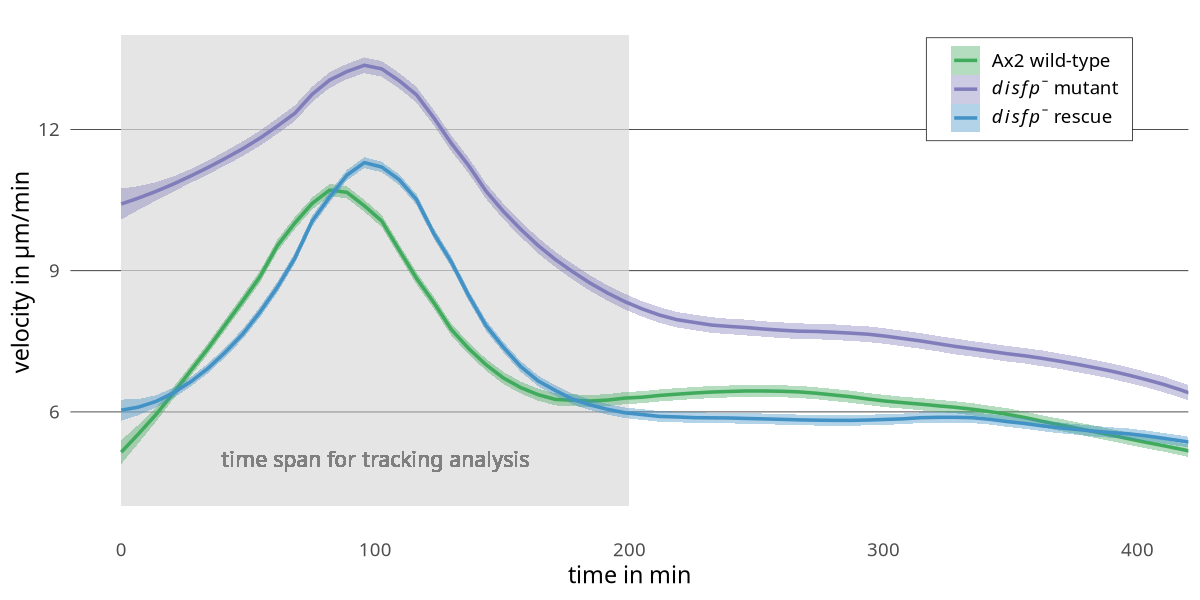

In [26]:
options(repr.plot.width = 10, repr.plot.height = 5)

# Parsed labels for legend
strain_rename_label <- c(
  "ko" = expression(italic(disfp)^"–" ~ "mutant"),
  "re" = expression(italic(disfp)^"–" ~ "rescue"), 
  "wt" = expression("Ax2 wild-type")
)

# Plot average migration speed per frame and strain
p_velocity <- tracking_data_speed_sum %>%
  arrange(frame, exp, strain) %>%
  ggplot(aes(x = frame / 2, y = mean_speed_um_per_sec, group = strain, fill = strain, color = strain)) +
    geom_rect(aes(xmin = 0, xmax = 200, ymin = 4, ymax = 14), fill = "grey80", alpha = 0.02, inherit.aes = FALSE) +  # Highlight analysis window
    geom_smooth(method = "loess", span = 0.25) +
    geom_text(aes(x = 100, y = 5, label = "time span for tracking analysis"), color = "grey50", size = 4.5) +
    scale_color_manual(values = strain_colors, labels = strain_rename_label,
                       guide = guide_legend(title = NULL)) +
    scale_fill_manual(values = strain_colors, labels = strain_rename_label,
                      guide = guide_legend(title = NULL)) +
    theme_minimal(base_size = 14) +
    coord_cartesian(xlim = c(0, 400)) +
    labs(x = "time in min", y = "velocity in µm/min") +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      panel.grid.major.y = element_line(color = "gray20", size = 0.25),
      legend.background = element_rect(fill = "white", colour = "grey20", size = 0.25), 
      legend.margin = margin(t = 5, r = 15, b = 5, l = 15),
      legend.position = c(0.95, 0.95),
      legend.justification = c("right", "top")
    )

p_velocity


### Combine plots for supplementary information

Warning message in geom_rect(aes(xmin = 0, xmax = 200, ymin = 4, ymax = 14), fill = "grey80", :
“All aesthetics have length 1, but the data has 9431 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”
`geom_smooth()` using formula = 'y ~ x'


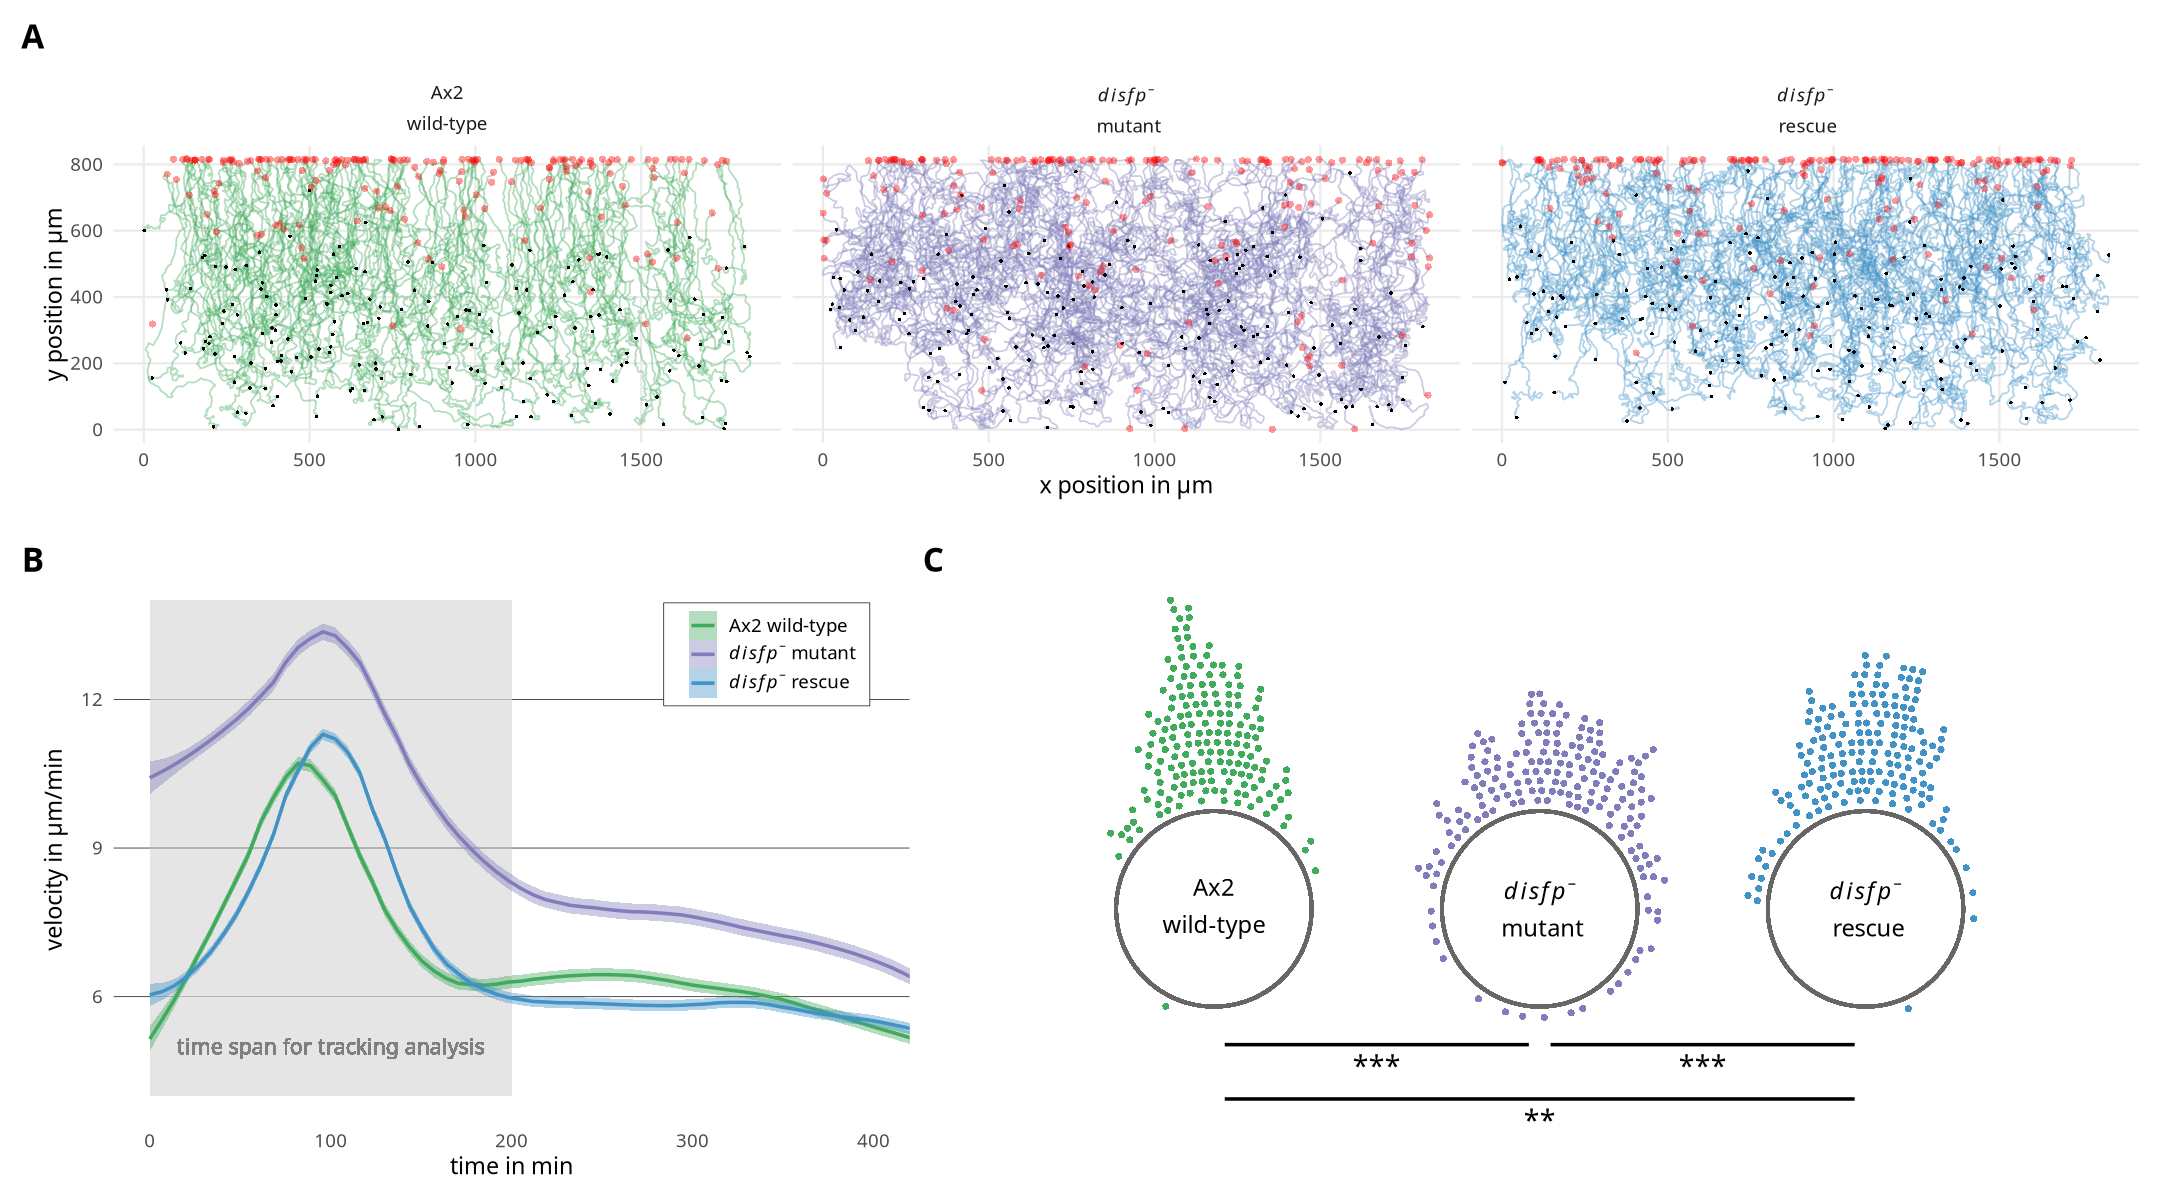

In [33]:
options(repr.plot.width = 18, repr.plot.height = 10)

plot_top <- p_raw_tracks
plot_bot <- (p_velocity + p_circle) + plot_layout(widths = c(2, 3))

# Combine all parts into a tagged figure layout
(plot_top / plot_bot) + 
  plot_layout(heights = c(1.25, 2)) &
  plot_annotation(tag_levels = 'A') &
  theme(plot.tag = element_text(face = "bold", size = 20))


### Export for main figures
Rescale plots for parallel FMI and directness and save as SVG.

In [28]:
# Boxplot: parallel FMI (y-axis)
p_FMI_y <- filtered_track_summary %>% 
  ggplot(aes(x = strain, y = total_FMI_y, fill = strain)) + 
  geom_boxplot(outlier.shape = NA, linewidth = 0.15) +
  geom_segment(data = annotations_fmi_y, aes(x = x_min, xend = x_max, y = y - 0.1, yend = y - 0.1),
               inherit.aes = FALSE, color = "black", size = 0.2) +
  geom_text(data = annotations_fmi_y, aes(x = (x_min + x_max) / 2, y = y - 0.15, label = label),
            inherit.aes = FALSE, nudge_y = 0.075, hjust = 0.5, size = 3) +
  scale_fill_manual(values = strain_colors) +
  scale_x_discrete(labels = strain_rename) +
  labs(x = NULL, y = "parallel FMI") +
  ylim(c(-0.1, 1.0)) +
  theme_minimal(base_size = 8) +
  guides(fill = FALSE, color = FALSE) +
  theme(panel.grid = element_blank())

# Boxplot: directness
p_directness <- filtered_track_summary %>% 
  ggplot(aes(x = strain, y = total_Directness, fill = strain)) + 
  geom_boxplot(outlier.shape = NA, linewidth = 0.15) +
  geom_segment(data = annotations_directness, aes(x = x_min, xend = x_max, y = y - 0.1, yend = y - 0.1),
               inherit.aes = FALSE, color = "black", size = 0.2) +
  geom_text(data = annotations_directness, aes(x = (x_min + x_max) / 2, y = y - 0.15, label = label),
            inherit.aes = FALSE, nudge_y = 0.075, hjust = 0.5, size = 3) +
  scale_fill_manual(values = strain_colors) +
  scale_x_discrete(labels = strain_rename) +
  labs(x = NULL, y = "directness") +
  ylim(c(-0.1, 1.05)) +
  theme_minimal(base_size = 8) +
  guides(fill = FALSE, color = FALSE) +
  theme(panel.grid = element_blank())

# Define final theme tweaks (axis ticks, spacing, etc.)
custom_theme <- theme_minimal(base_size = 8) +
  theme(
    axis.title = element_text(color = "black"),
    axis.text = element_text(color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.border = element_blank(),
    panel.spacing = unit(0.5, "lines"),
    panel.grid = element_blank(),
    panel.grid.major.y = element_line(color = "grey75", size = 0.15),
    axis.line.x = element_line(color = "black", size = 0.15),
    axis.ticks = element_blank(),
    strip.text = element_text(face = "bold", size = 8, color = "black"),
    legend.position = "none"
  )

# Save combined figure
save_path <- file.path(wd, "05_results", "img", "p_FMI_y.svg")
ggsave(
  save_path,
  plot = p_FMI_y + p_directness & custom_theme,
  width = 87 / 25.4, height = 45.5 / 25.4,
  units = "in", bg = "transparent", device = svglite
)

# Display inline preview (Jupyter only)
display_html(sprintf('<img src="%s" style="height:1.5vh; width:auto; background-color:white;">', save_path))


Warning message:
“Removed 15 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
